In [ ]:
!pip uninstall pandas numpy -y -q
#uninstalling the existing pandas and numpy libary with automatic confirmation
!pip install numpy==1.26.4 pandas==2.2.2 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 178.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 180.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 196.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 170.0 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.1.post1
    Uninstalling pytz-2026.1.post1:
      Successfully uninstalled pytz-2026.1.post1
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.2
    Uninstalling tzdata-2026.2:
      Successfully uninstalled tzdata-2026.2
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: python-dateutil
    Found exis

In [ ]:
!pip install scikit-surprise joblib torch

In [ ]:
from google.colab import files
files.upload()

Saving best_svd.pkl to best_svd (1).pkl
Saving content_recommender.joblib to content_recommender (1).joblib
Saving ncf_model_checkpoint_v4.pt to ncf_model_checkpoint_v4 (1).pt
Saving bert4rec_max_checkpoint.pt to bert4rec_max_checkpoint (1).pt
Buffered data was truncated after reaching the output size limit.

In [153]:
import hashlib
import random
import pandas as pd
import torch
import joblib

In [154]:
#-----Helper Functions-----
def assign_variant(user_id):
        hash_val = int(hashlib.md5(str(user_id).encode()).hexdigest(), 16)
        return "A" if hash_val % 2 else "B"
        #A is the control, B is for the model being tested


def log_event(logs, user_id, variant, event_type, movie_id):
    logs.append({
        'user_id': user_id,
        'variant': variant,
        'event': event_type,
        'movie_id': movie_id
    })

def simulate_clicks(logs, user_id, variant, recs, click_prob=0.2):
    for _, row in recs.iterrows():
        if random.random() < click_prob:
            log_event(logs, user_id, variant, 'click', row['movieId'])

def compute_ctr(df):
    summary = df.groupby(['variant', 'event']).size().unstack(fill_value=0)
    summary['CTR'] = summary['click'] / summary['impression']
    return summary

In [155]:
#-----Recommenders-----
def get_popularity_recommendations(user_id, ratings, movies, popular_movie_ids, n=10):
    seen = set(ratings[ratings['userId'] == user_id]['movieId'].tolist())

    recs = []
    for mid in popular_movie_ids:
        if mid not in seen:
            row = movies[movies['movieId'] == mid].iloc[0]
            recs.append({
                'movieId': mid,
                'title': row['title'],
                'genres': row['genres'],
                'predicted_rating': None
            })

            if len(recs) >= n:
                break

    return pd.DataFrame(recs)

def get_svd_recommendations(user_id, ratings, movies, svd_model, n=10):
        rated = ratings[ratings['userId'] == user_id]['movieId'].tolist()
        unrated = [m for m in movies['movieId'].tolist() if m not in rated]

        preds = [svd_model.predict(user_id, mid) for mid in unrated]
        preds.sort(key=lambda x: x.est, reverse=True)

        results = []
        for pred in preds[:n]:
            row = movies[movies['movieId'] == pred.iid].iloc[0]
            results.append({
                'movieId': pred.iid,
                'title': row['title'],
                'genres': row['genres'],
                'predicted_rating': round(pred.est, 2)
            })

        return pd.DataFrame(results)

def get_content_recommendations(user_id, ratings, movies, n=10):
        user_data = ratings[ratings['userId'] == user_id]

        liked_movies = user_data[user_data['rating'] >= 4]['movieId']
        if liked_movies.empty:
            return pd.DataFrame()

        liked_genres = movies[movies['movieId'].isin(liked_movies)]['genres']

        genre_counts = {}
        for genres in liked_genres:
            for g in genres.split('|'):
                genre_counts[g] = genre_counts.get(g, 0) + 1

        total = sum(genre_counts.values())
        for g in genre_counts:
            genre_counts[g] /= total

        seen = set(user_data['movieId'])
        candidates = movies[~movies['movieId'].isin(seen)]

        scores = []
        for _, row in candidates.iterrows():
            movie_genres = row['genres'].split('|')
            score = sum(genre_counts.get(g, 0) for g in movie_genres)
            scores.append((row['movieId'], score))

        scores.sort(key=lambda x: x[1], reverse=True)

        results = []
        for mid, score in scores[:n]:
            row = movies[movies['movieId'] == mid].iloc[0]
            results.append({
                'movieId': mid,
                'title': row['title'],
                'genres': row['genres'],
                'predicted_rating': round(score, 3)
            })

        return pd.DataFrame(results)

def get_ncf_recommendations(user_id, ratings, movies, ncf_model, n=10):
        rated = ratings[ratings['userId'] == user_id]['movieId'].tolist()
        all_movies = movies['movieId'].tolist()
        unrated = [m for m in all_movies if m not in rated]

        preds = []
        for mid in unrated:
          try:
            encoded_user = user_encoder.transform([user_id])[0]
            encoded_item = movie_encoder.transform([mid])[0]
          except:
            continue

          user_tensor = torch.LongTensor([encoded_user])
          item_tensor = torch.LongTensor([encoded_item])
          genre_tensor = torch.tensor([genre_matrix[encoded_item]])

          with torch.no_grad():
            rating, _, _ = ncf_model(user_tensor, item_tensor, genre_tensor)
            score = rating.item()

          preds.append((mid, score))

        preds.sort(key=lambda x: x[1], reverse=True)

        results = []
        for mid, score in preds[:n]:
            row = movies[movies['movieId'] == mid].iloc[0]
            results.append({
                'movieId': mid,
                'title': row['title'],
                'genres': row['genres'],
                'predicted_rating': round(score, 2)
            })

        return pd.DataFrame(results)

In [156]:
#-----A/B Test Runner-----
def run_single_ab_test(model_name, model_func, ratings, movies, popular_movie_ids, svd_model=None, ncf_model=None):
        logs = []
        NUM_USERS = 500
        TOP_N = 10
        users = random.sample(list(ratings['userId'].unique()), NUM_USERS)

        for user_id in users:
            variant = assign_variant(user_id)

            if variant == "A":
                recs = get_popularity_recommendations(user_id, ratings, movies, popular_movie_ids, TOP_N)
            else:
                if model_name == "svd":
                    recs = model_func(user_id, ratings, movies, svd_model, TOP_N)
                elif model_name == "ncf":
                    recs = model_func(user_id, ratings, movies, ncf_model, TOP_N)
                else:
                    recs = model_func(user_id, ratings, movies, None, TOP_N)

        # log impressions
            for _, row in recs.iterrows():
                log_event(logs, user_id, variant, 'impression', row['movieId'])

            simulate_clicks(logs, user_id, variant, recs)

        return pd.DataFrame(logs)

In [157]:
def load_data():
  ratings = pd.read_csv("ratings.csv")
  movies = pd.read_csv("movies.csv")
  return ratings, movies

ratings, movies = load_data()

popularity = ratings.groupby('movieId').size().sort_values(ascending=False)
popular_movie_ids = popularity.index.tolist()

In [158]:
import torch
import torch.nn as nn

class AttentionScorer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W_q   = nn.Linear(dim, dim, bias=False)
        self.W_k   = nn.Linear(dim, dim, bias=False)
        self.scale = dim ** 0.5

    def forward(self, user_emb, movie_emb):
        q = self.W_q(user_emb)
        k = self.W_k(movie_emb)
        return (q * k).sum(dim=-1) / self.scale


class WideAndDeepNCF(nn.Module):
    def __init__(self, n_users, n_movies, n_genres,
                 embed_dim=64, mlp_layers=(256, 128, 64), dropout=0.3):
        super().__init__()

        self.user_emb    = nn.Embedding(n_users,  embed_dim)
        self.movie_emb   = nn.Embedding(n_movies, embed_dim)
        self.user_bias   = nn.Embedding(n_users,  1)
        self.movie_bias  = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        layers, in_dim = [], embed_dim * 2
        for out_dim in mlp_layers:
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_dim = out_dim

        self.deep_mlp    = nn.Sequential(*layers)
        self.deep_out    = nn.Linear(mlp_layers[-1], 1)
        self.wide_linear = nn.Linear(n_genres, 1, bias=True)
        self.attention   = AttentionScorer(embed_dim)
        self.alpha       = nn.Parameter(torch.tensor(0.5))

    def forward(self, user, movie, genres, return_attention=False):
        u  = self.user_emb(user)
        m  = self.movie_emb(movie)
        ub = self.user_bias(user).squeeze(1)
        mb = self.movie_bias(movie).squeeze(1)

        deep_score = self.deep_out(
            self.deep_mlp(torch.cat([u, m], dim=1))
        ).squeeze(1)

        wide_score = self.wide_linear(genres).squeeze(1)
        attn       = self.attention(u, m)

        a      = torch.sigmoid(self.alpha)
        raw    = a * deep_score + (1 - a) * wide_score + ub + mb + self.global_bias
        rating = torch.sigmoid(raw) * 4 + 1

        cosine_target = (
            nn.functional.cosine_similarity(u.detach(), m.detach(), dim=1) + 1
        ) / 2

        if return_attention:
            return rating, attn
        return rating, cosine_target, attn

In [159]:
ckpt = torch.load("/content/ncf_model_checkpoint_v4.pt", weights_only=False)

In [160]:
config = ckpt["config"]
encoders = ckpt["encoders"]
genre_matrix = ckpt["genre_matrix"]

print(encoders.keys())
user_encoder = encoders["user_enc"]
movie_encoder = encoders["movie_enc"]

dict_keys(['user_enc', 'movie_enc'])


In [161]:
ncf_model = WideAndDeepNCF(
    n_users=config['n_users'],
    n_movies=config['n_movies'],
    n_genres=config['n_genres'],
    embed_dim=config['embed_dim'],
    mlp_layers=config['mlp_layers'],
    dropout=config['dropout']
)

In [163]:
ncf_model.load_state_dict(ckpt["model_state_dict"])
ncf_model.eval()

WideAndDeepNCF(
  (user_emb): Embedding(6040, 64)
  (movie_emb): Embedding(3706, 64)
  (user_bias): Embedding(6040, 1)
  (movie_bias): Embedding(3706, 1)
  (deep_mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (deep_out): Linear(in_features=64, out_features=1, bias=True)
  (wide_linear): Linear(in_features=18, out_features=1, bias=True)
  (attention): AttentionScorer(
    (W_q): Linear(in_features=64, out_features=64, bias=Fal

In [164]:
svd_model = joblib.load("/content/best_svd.pkl")
content_model = joblib.load("/content/content_recommender.joblib")

In [165]:
def popularity_wrapper(user_id, ratings, movies, model, n):
    return get_popularity_recommendations(user_id, ratings, movies, popular_movie_ids, n)

def svd_wrapper(user_id, ratings, movies, model, n):
    return get_svd_recommendations(user_id, ratings, movies, model, n)

def content_wrapper(user_id, ratings, movies, model, n):
    return get_content_recommendations(user_id, ratings, movies, n)

def ncf_wrapper(user_id, ratings, movies, model, n):
    return get_ncf_recommendations(user_id, ratings, movies, model, n)

In [166]:
results = {}

In [167]:
def run_ab_test():

    results['svd'] = compute_ctr(
        run_single_ab_test("svd", svd_wrapper, ratings, movies, popular_movie_ids, svd_model=svd_model)
        )
    results['content'] = compute_ctr(
        run_single_ab_test("content", content_wrapper, ratings, movies, popular_movie_ids)
    )
    results['ncf'] = compute_ctr(
        run_single_ab_test("ncf", ncf_wrapper, ratings, movies, popular_movie_ids, ncf_model=ncf_model)
    )

    results["popularity"] = compute_ctr(
        run_single_ab_test("popularity", popularity_wrapper, ratings, movies, popular_movie_ids)
    )


    print("\n===== A/B TEST RESULTS =====")
    for name, res in results.items():
        print(f"\nModel: {name.upper()}")
        print(res)

    return results

In [168]:
if __name__ == "__main__":
    results = run_ab_test()


===== A/B TEST RESULTS =====

Model: SVD
event    click  impression       CTR
variant                             
A          478        2330  0.205150
B          557        2670  0.208614

Model: CONTENT
event    click  impression       CTR
variant                             
A          481        2440  0.197131
B          528        2560  0.206250

Model: NCF
event    click  impression       CTR
variant                             
A          450        2210  0.203620
B          557        2790  0.199642

Model: POPULARITY
event    click  impression       CTR
variant                             
A          476        2380  0.200000
B          563        2620  0.214885


In [169]:
def get_relevant_items(df):
    return df[df["event"] == "click"].groupby("user_id")["movie_id"].apply(set)

In [170]:
def precision_recall_at_k(logs, k=10):
    relevant = get_relevant_items(logs)

    grouped = logs[logs["event"] == "impression"].groupby("user_id")["movie_id"].apply(list)

    precisions, recalls = [], []

    for user, items in grouped.items():
        items = items[:k]
        rel = relevant.get(user, set())

        if len(items) == 0:
            continue

        hits = len(set(items) & rel)

        precisions.append(hits / k)
        recalls.append(hits / max(1, len(rel)))

    return sum(precisions)/len(precisions), sum(recalls)/len(recalls)

In [171]:
import math

def ndcg_at_k(logs, k=10):
    relevant = get_relevant_items(logs)

    grouped = logs[logs["event"] == "impression"].groupby("user_id")["movie_id"].apply(list)

    scores = []

    for user, items in grouped.items():
        items = items[:k]
        rel = relevant.get(user, set())

        dcg = 0
        for i, item in enumerate(items):
            if item in rel:
                dcg += 1 / math.log2(i + 2)

        idcg = sum(1 / math.log2(i + 2) for i in range(min(len(rel), k)))

        scores.append(dcg / idcg if idcg > 0 else 0)

    return sum(scores)/len(scores)

In [172]:
metrics = {}
metrics["SVD"] = {}
metrics["Content"] = {}
metrics["NCF"] = {}
metrics["Popularity"] = {}

In [173]:
metrics["SVD"]["CTR"] = results["svd"].loc["B", "CTR"]
metrics["Content"]["CTR"] = results["content"].loc["B", "CTR"]
metrics["NCF"]["CTR"] = results["ncf"].loc["B", "CTR"]
metrics["Popularity"]["CTR"] = results["popularity"].loc["A", "CTR"]

In [174]:
svd_logs = run_single_ab_test("svd", svd_wrapper, ratings, movies, popular_movie_ids, svd_model=svd_model)
content_logs = run_single_ab_test("content", content_wrapper, ratings, movies, popular_movie_ids)
ncf_logs = run_single_ab_test("ncf", ncf_wrapper, ratings, movies, popular_movie_ids, ncf_model=ncf_model)


In [175]:
pop_logs = run_single_ab_test("popularity", popularity_wrapper, ratings, movies, popular_movie_ids)

In [176]:
all_logs = {
    "SVD": svd_logs,
    "Content": content_logs,
    "NCF": ncf_logs,
    "Popularity": pop_logs
}

In [177]:
for name, logs in all_logs.items():
    p, r = precision_recall_at_k(logs)
    ndcg = ndcg_at_k(logs)

    metrics[name]["Precision@10"] = p
    metrics[name]["Recall@10"] = r
    metrics[name]["NDCG@10"] = ndcg

In [178]:
final_table = pd.DataFrame(metrics).T
print(final_table)

                 CTR  Precision@10  Recall@10   NDCG@10
SVD         0.208614        0.2012      0.880  0.491298
Content     0.206250        0.1986      0.900  0.500873
NCF         0.199642        0.2052      0.886  0.507496
Popularity  0.200000        0.2052      0.886  0.516141


In [179]:
final_table.to_csv("ab_test_results.csv")

In [180]:
from statsmodels.stats.proportion import proportions_ztest

def run_ctr_ztest(summary_df):
    clicks = summary_df['click'].values
    impressions = summary_df['impression'].values

    z_stat, p_val = proportions_ztest(clicks, impressions)

    return z_stat, p_val

In [181]:
stat_results = {}

for name, summary in results.items():
    z, p = run_ctr_ztest(summary)

    stat_results[name] = {
        "z_stat": z,
        "p_value": p
    }

In [182]:
for model, stats in stat_results.items():
    print(f"\nModel: {model.upper()}")
    print(f"Z-stat: {stats['z_stat']:.4f}")
    print(f"P-value: {stats['p_value']:.6f}")


Model: SVD
Z-stat: -0.3016
P-value: 0.762970

Model: CONTENT
Z-stat: -0.8031
P-value: 0.421934

Model: NCF
Z-stat: 0.3484
P-value: 0.727575

Model: POPULARITY
Z-stat: -1.2956
P-value: 0.195107


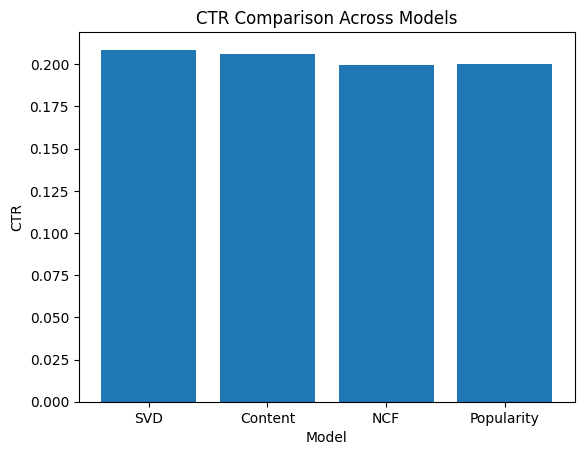

In [183]:
import matplotlib.pyplot as plt

ctr_values = {
    "SVD": metrics["SVD"]["CTR"],
    "Content": metrics["Content"]["CTR"],
    "NCF": metrics["NCF"]["CTR"],
    "Popularity": metrics["Popularity"]["CTR"]
}

plt.figure()
plt.bar(ctr_values.keys(), ctr_values.values())

plt.title("CTR Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("CTR")

plt.show()

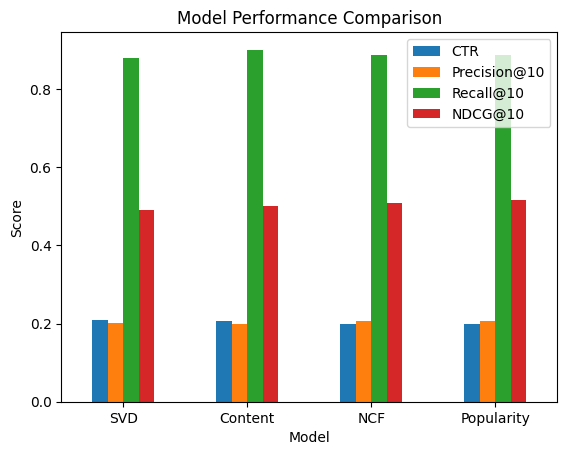

In [184]:
metrics_df = pd.DataFrame(metrics).T

metrics_df.plot(kind="bar")

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=0)
plt.legend(loc="best")

plt.show()

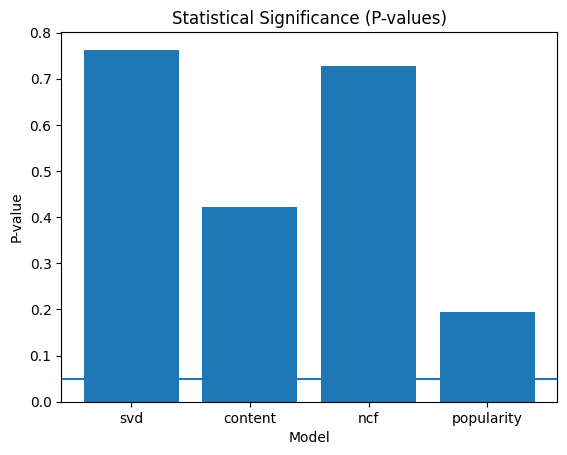

In [185]:
p_values = {
    model: stat_results[model]["p_value"]
    for model in stat_results
}

plt.figure()
plt.bar(p_values.keys(), p_values.values())

plt.axhline(y=0.05)  # significance threshold

plt.title("Statistical Significance (P-values)")
plt.xlabel("Model")
plt.ylabel("P-value")

plt.show()

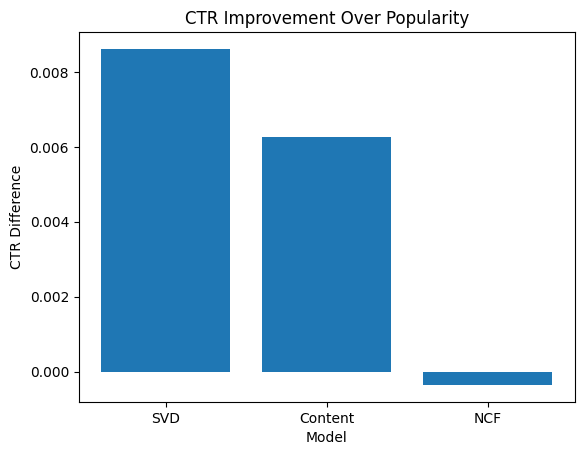

In [186]:
baseline_ctr = metrics["Popularity"]["CTR"]

ctr_diff = {
    model: metrics[model]["CTR"] - baseline_ctr
    for model in ["SVD", "Content", "NCF"]
}

plt.figure()
plt.bar(ctr_diff.keys(), ctr_diff.values())

plt.title("CTR Improvement Over Popularity")
plt.xlabel("Model")
plt.ylabel("CTR Difference")

plt.show()